In [2]:
import pandas as pd
import matplotlib.pyplot as plt

Task: 

Given student data involving test scores (**X**), a cutoff, and an outcome (Y), which measures whether the students got into college (as in the example in the text), determine whether the math course helps students get into college in each dataset. Use datasets homework_4.2.a and homework_4.2.b. 

In [3]:
df_a = pd.read_csv('homework_4.2.a.csv')
df_a

,X,Y
0,81.822339,1
1,92.487870,0
2,85.372460,0
3,78.828025,0
4,75.807080,1
...,...,...
99995,92.542635,1
99996,81.713212,0
99997,76.949186,0
99998,71.790575,0


In [4]:
df_b = pd.read_csv('homework_4.2.b.csv')
df_b

,X2,Y2
0,76.643034,1
1,87.743397,1
2,81.639469,1
3,73.740485,0
4,90.480268,1
...,...,...
99995,75.857481,0
99996,87.572107,1
99997,81.230748,1
99998,86.646018,1


In [5]:
# I guess i'll assume 0.8 cutoff since one is not given
import statsmodels.api as sm
import statsmodels.formula.api as smf

cutoff = 80.0

# bandwidth = 5.00  # This looks at 0.75 to 0.85
bandwidth = 1.00  # This looks at 0.79 to 0.81

# Filter the dataset to only include people in this narrow window
df_local = df_a[df_a['X'].between(cutoff - bandwidth, cutoff + bandwidth)].copy()

# Recalculate your centered variable and treatment indicator on this local data
df_local['X_centered'] = df_local['X'] - cutoff
df_local['Treatment'] = (df_local['X'] >= cutoff).astype(int)

# 2. Fit the model with an interaction term 
# This allows for different regression slopes on each side of the cutoff
model = smf.ols("Y ~ X_centered * Treatment", data=df_local).fit()

# 3. Display the regression table
print(model.summary())

# The coefficient for 'Treatment' is your estimated Local Average Treatment Effect (LATE)
print(f"Estimated Treatment Effect: {model.params['Treatment']:.4f}")

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.082
Model:                            OLS   Adj. R-squared:                  0.081
Method:                 Least Squares   F-statistic:                     239.6
Date:                Thu, 18 Jun 2026   Prob (F-statistic):          6.11e-149
Time:                        11:52:26   Log-Likelihood:                -5479.1
No. Observations:                8078   AIC:                         1.097e+04
Df Residuals:                    8074   BIC:                         1.099e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                0.3201 

In [6]:
# We can see slope decreased after treatment (slightly [-0.0165])
model.params['X_centered:Treatment']

np.float64(-0.01646485397868115)

Q3. Is **Y**'s slope higher or lower after the cutoff compared with before? 

A. Lower

B. Higher

A3. Lower (but not confident)

Q4. In that dataset, is **Y** increasing or decreasing before the cutoff? 

A. Decreasing

B. Increasing

In [7]:
# We can see 0.0262. Y is increasing (slightly) before the treatment
model.params['X_centered']

np.float64(0.026202257533137013)

A4. Increasing (but not confident)

Q5. Given a cutoff score of 80, which dataset seems most likely to involve a nonzero linear term, allowing **Y** to relate linearly to **X** before and after the cutoff? 

A. Dataset b (X2, Y2)

B. Dataset a (X, Y)

In [8]:
import statsmodels.formula.api as smf

# Center the running variables around the cutoff (80)
df_a['X_centered'] = df_a['X'] - 80
df_a['Treatment'] = (df_a['X'] >= 80).astype(int)

df_b['X2_centered'] = df_b['X2'] - 80
df_b['Treatment'] = (df_b['X2'] >= 80).astype(int)

# Fit the models for both datasets
model_a = smf.ols('Y ~ X_centered * Treatment', data=df_a).fit()
model_b = smf.ols('Y2 ~ X2_centered * Treatment', data=df_b).fit()

print("--- DATASET A RESULTS ---")
print(model_a.summary())

print("\n--- DATASET B RESULTS ---")
print(model_b.summary())


--- DATASET A RESULTS ---
                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.090
Model:                            OLS   Adj. R-squared:                  0.090
Method:                 Least Squares   F-statistic:                     3300.
Date:                Thu, 18 Jun 2026   Prob (F-statistic):               0.00
Time:                        11:52:26   Log-Likelihood:                -67412.
No. Observations:              100000   AIC:                         1.348e+05
Df Residuals:                   99996   BIC:                         1.349e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Interc

A5. A since p value is way lower

2. Plot the college outcome (Y) vs. the test score (X) in a small range of test scores around 80. On the plot, compare it with the Y probability predicted by logistic regression. The ground truth Y value is 0 or 1; don't just plot 0 or 1 - that will make it unreadable.  Find some way to make it look better than that.

In [9]:
df_b

,X2,Y2,X2_centered,Treatment
0,76.643034,1,-3.356966,0
1,87.743397,1,7.743397,1
2,81.639469,1,1.639469,1
3,73.740485,0,-6.259515,0
4,90.480268,1,10.480268,1
...,...,...,...,...
99995,75.857481,0,-4.142519,0
99996,87.572107,1,7.572107,1
99997,81.230748,1,1.230748,1
99998,86.646018,1,6.646018,1


In [10]:
df_a[['X', 'Y']]

,X,Y
0,81.822339,1
1,92.487870,0
2,85.372460,0
3,78.828025,0
4,75.807080,1
...,...,...
99995,92.542635,1
99996,81.713212,0
99997,76.949186,0
99998,71.790575,0


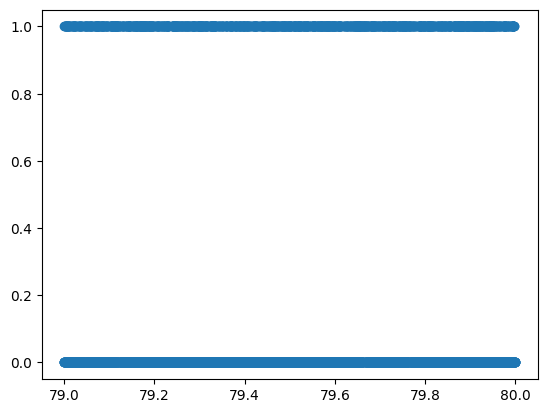

In [11]:
df_around_80 = df_a[df_a['X'].between(79,80)]

plt.scatter(df_around_80['X'], df_around_80['Y'])
None

c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


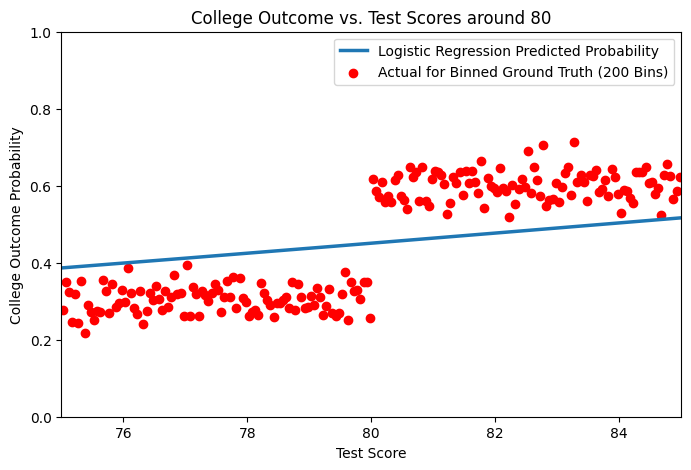

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# --- 1. Define Range & Fit Model ---
# Focus on a tight window around the target test score of 80
x_min, x_max = 75, 85  

# Fit the logistic regression model on your dataframe 'df'
model = LogisticRegression()
model.fit(df_a[['X']], df_a['Y'])

# --- 2. Process Ground Truth (Binned Averages) ---
# Filter data to the small range around 80
df_range = df_a[(df_a['X'] >= x_min) & (df_a['X'] <= x_max)].copy()

# Group test scores into discrete bins to calculate actual success rates
df_range['bin'] = pd.cut(df_range['X'], bins=200)
binned_data = df_range.groupby('bin', observed=False).agg({'X': 'mean', 'Y': 'mean'}).dropna()

# --- 3. Generate Predictions for the Smooth Curve ---
X_smooth = np.linspace(x_min, x_max, 300).reshape(-1, 1)
Y_predicted_prob = model.predict_proba(X_smooth)[:, 1]

# --- 4. Plotting ---
plt.figure(figsize=(8, 5))

# Plot the continuous prediction curve
plt.plot(X_smooth, Y_predicted_prob, linewidth=2.5, 
         label='Logistic Regression Predicted Probability')

# Plot the clean, aggregated ground truth proportions
plt.scatter(binned_data['X'], binned_data['Y'], color='red', 
           label='Actual for Binned Ground Truth (200 Bins)')

# Formatting details
plt.title('College Outcome vs. Test Scores around 80')
plt.xlabel('Test Score')
plt.ylabel('College Outcome Probability')
plt.xlim(x_min, x_max)
plt.ylim(0, 1.0)
plt.legend()
plt.show()


Reflection problem:

Plot the college outcome (Y) vs. the test score (X) in a small range of test scores around 80. 

On the plot, compare it with the Y probability predicted by logistic regression. The ground truth Y value is 0 or 1; don't just plot 0 or 1 - that will make it unreadable.  Find some way to make it look better than that.